In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV

df = pd.read_csv('Data/ACME-HappinessSurvey2020.csv')
df.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


# Checking data types

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


Missing Values

In [16]:
df.isna().sum()/len(df)

Y     0.0
X1    0.0
X2    0.0
X3    0.0
X4    0.0
X5    0.0
X6    0.0
dtype: float64

Correlation matrix analysis

<Axes: >

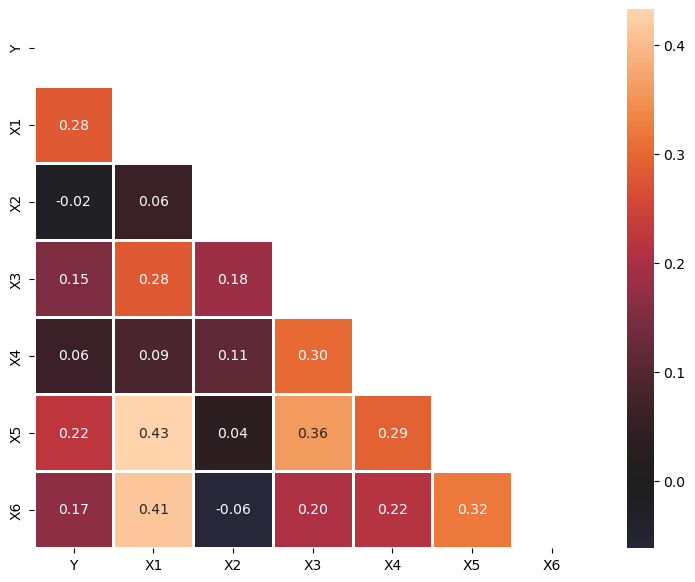

In [17]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr))
sns.heatmap(corr, center=0,
            mask=mask,
              linewidths=1,
              annot=True,
                fmt=".2f"
)

Outliers Analysis quantile method

In [19]:
q1_q = df['X1'].quantile(0.25)
q3_q = df['X1'].quantile(0.75)
# Find the IQR
IQR = q3_q - q1_q
factor = 2.5 # 2.5 × IQR means you only mark really extreme points as outliers
lower_limit_q = q1_q - IQR*factor
upper_limit_q = q3_q + IQR*factor

is_lower_q = df['X1'] < lower_limit_q

is_higher_q = df['X1'] > upper_limit_q
# Combine the masks to filter for outliers
outliers = df['X1'][is_lower_q | is_higher_q] 
# Count and print the number of outliers
print(len(outliers))

1


Feature engineering is not part of this project as there are only 6 variables and I can not derive anything

# Building the models

In [20]:
y = df['Y']
X = df.drop('Y',axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2, random_state=42, stratify= y )

In [21]:
normal_tree = DecisionTreeClassifier(random_state=42,
                                     class_weight='balanced')

In [22]:
normal_tree.fit(X_train, y_train)
y_pred = normal_tree.predict(X_test)
labels = [' Not Happy', 'Happy']
print(classification_report(y_test,
                            y_pred,
                            target_names=labels))

              precision    recall  f1-score   support

   Not Happy       0.53      0.75      0.62        12
       Happy       0.67      0.43      0.52        14

    accuracy                           0.58        26
   macro avg       0.60      0.59      0.57        26
weighted avg       0.60      0.58      0.57        26



In [23]:
rf = RandomForestClassifier(random_state=42,  
                            class_weight='balanced')

In [24]:
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
labels = [' Not Happy', 'Happy']
print(classification_report(y_test,
                            y_pred,
                            target_names=labels))

              precision    recall  f1-score   support

   Not Happy       0.60      0.75      0.67        12
       Happy       0.73      0.57      0.64        14

    accuracy                           0.65        26
   macro avg       0.66      0.66      0.65        26
weighted avg       0.67      0.65      0.65        26



# Random Search 

In [29]:

max_depth_list = list(range(2,40))
min_samples_split_list = list(range(2,20))
n_estimators_list = list(range(200,1000))
min_samples_leaf_list = list(range(2,10))

parameter_grid = {
'max_depth': max_depth_list,
'min_samples_split': min_samples_split_list,
'n_estimators' : n_estimators_list,
'min_samples_leaf' : min_samples_leaf_list
}

number_models = 10

random_RF_class = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=parameter_grid,
    n_iter=number_models,
    scoring='accuracy',
    n_jobs=-1,
    cv=5,
)
random_RF_class.fit(X_train, y_train)


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20, 21,
                                                      22, 23, 24, 25, 26, 27,
                                                      28, 29, 30, 31, ...],
                                        'min_samples_leaf': [2, 3, 4, 5, 6, 7,
                                                             8, 9],
                                        'min_samples_split': [2, 3, 4, 5, 6, 7,
                                                              8, 9, 10, 11, 12,
                                                              13, 14, 15, 16,
                                                              17, 18, 19],
                                        'n_estimators': [200, 201, 202, 203,
                                                         204, 205, 206, 207,
                                                         208, 209, 210, 211,
                                                         212, 213, 214, 215,
                                                         216, 217, 218, 219,
                                                         220, 221, 222, 223,
                                                         224, 225, 226, 227,
                                                         228, 229, ...]},
                   scoring='accuracy')

In [30]:
rand_x = random_RF_class.cv_results_['param_max_depth']
rand_y = random_RF_class.cv_results_['param_min_samples_leaf']
rand_z = random_RF_class.cv_results_['param_n_estimators']
rand_w = random_RF_class.cv_results_['param_min_samples_split']

In [31]:
print("max_depth:", rand_x)
print("min_samples_leaf:", rand_y)
print("n_estimators:", rand_z)
print("min_samples_split:", rand_w)

max_depth: [16 17 7 35 20 18 8 10 10 3]
min_samples_leaf: [4 5 2 3 2 8 7 2 4 4]
n_estimators: [475 675 313 247 786 587 269 941 338 715]
min_samples_split: [2 6 19 10 2 17 4 11 11 18]


In [32]:
random_RF_class.best_params_

{'n_estimators': 675,
 'min_samples_split': 6,
 'min_samples_leaf': 5,
 'max_depth': 17}

# Optimized model

In [33]:
rf_tuned = RandomForestClassifier(random_state=42,  
                            class_weight='balanced',
                            max_depth = 17,
                            min_samples_leaf = 5,
                            min_samples_split = 6,
                            n_estimators = 675
                           )

In [34]:
rf_tuned.fit(X_train, y_train)
y_pred = rf_tuned.predict(X_test)
labels = [' Not Happy', 'Happy']
print(classification_report(y_test,
                            y_pred,
                            target_names=labels))

              precision    recall  f1-score   support

   Not Happy       0.75      0.75      0.75        12
       Happy       0.79      0.79      0.79        14

    accuracy                           0.77        26
   macro avg       0.77      0.77      0.77        26
weighted avg       0.77      0.77      0.77        26



# Feature importance for feature selection

Feature importance helps identify which features the model relied on most heavily when making predictions. In this section, I progressed from a simple representation of feature importance to more advanced and informative visualization methods.

<BarContainer object of 6 artists>

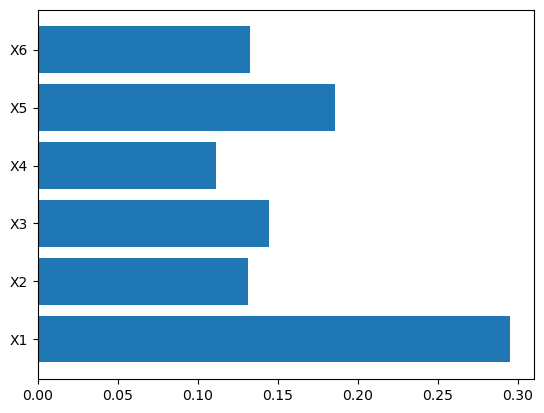

In [22]:
plt.barh(X_train.columns,
         rf_tuned.feature_importances_)

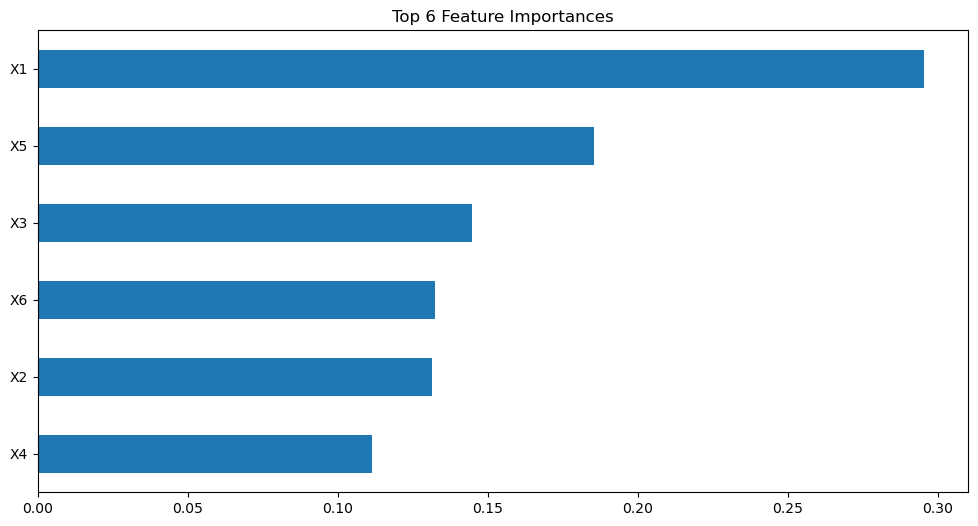

In [23]:
importances = pd.Series(rf_tuned.feature_importances_, index=X_train.columns)
# A series is a better representation than using a dictionary 
# index is needed for the labels
top_6_features = importances.sort_values(ascending=False)
# sort first for the importance, then sort again for the visual order of the values
top_6_features.sort_values().plot(kind='barh', figsize=(12,6))
# A horizontal bar chart is much better than a vertical bar chart to represent importance
plt.title("Top 6 Feature Importances")
plt.show()

In [ ]:
importances

Findings: X1 is the most important feature for predicting customer happiness. X3 represents the statement, 'My order was delivered on time.' On the other hand, X4 is the least important feature, representing 'I paid a good price for my order.'

Number 1 is X1 = my order was delivered on time
Number 2 is X5 = I am satisfied with my courier
Number 3 is X3 = I ordered everything I wanted to order


# Permutation Feature Importance 

The idea is that if the signal of the features is shuffled and destroyed, how much effect will it have on the model on seen and unseen data

In [25]:
importance = pd.Series(permutation_importance(rf_tuned, X_train, y_train, n_repeats=50).importances_mean, index=X_test.columns)
# shuffling each feature 50 times to provide a better result of stability 
print(importance.sort_values(ascending=False))

X1    0.1160
X5    0.0440
X3    0.0278
X6    0.0274
X4    0.0236
X2    0.0142
dtype: float64


In [24]:
importance = pd.Series(permutation_importance(rf_tuned, X_test, y_test, n_repeats=50).importances_mean, index=X_test.columns)
print(importance.sort_values(ascending=False))

X1    0.113077
X5    0.039231
X3    0.033846
X4    0.030000
X2    0.017692
X6    0.003077
dtype: float64


Findings: There is almost no difference between seen and unseen data 

Conclusion: Interestingly, shuffling X1 results in an 11% drop in model performance, indicating that X1 represents a strong predictive signal for the model. Based on the feature importance results, retaining X1, X5, and X3 appears well justified. X6 and X2 could also be considered, while X4 could be considered for removal, as it provides the weakest predictive signal among the features.